<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/Homework2026/2026/HW/HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 5: Classifying Stars with Machine Learning (42 pts)

## Learning Outcomes

- Understand how **Machine Learning** works: learning patterns from data instead of writing explicit rules
- See how **physical properties of stars** (temperature, color, luminosity) map to classification categories
- Use **scikit-learn** to train and compare classifiers (Decision Tree, k-Nearest Neighbors, Random Forest)
- Evaluate classifiers using **accuracy, confusion matrices, and feature importance**
- Understand when and why **feature scaling** matters for distance-based algorithms
- Create **publication-quality plots** of model comparisons and evaluation metrics
- Reflect on the difference between **Machine Learning and Artificial Intelligence**
- Submit homework via **fork and pull request**

## Development Environment

You have two options for working on this homework:

### Option A: GitHub Codespaces (recommended)

**GitHub Codespaces** gives you a cloud-based VS Code environment with Python, Jupyter, and all dependencies pre-installed — no setup needed.

> **If you have an existing Codespace from HW4**: you need to create a **new** one for HW5. The environment now includes `scikit-learn` which wasn't in the HW4 setup. See [Issue #69](https://github.com/ubsuny/PHY386/issues/69) for step-by-step instructions on saving your work before deleting the old Codespace.
>
> **Quick alternative**: run `pip install -r requirements/requirements_HW2026.txt` in your existing Codespace terminal.

1. **Fork the repository**: Go to [github.com/ubsuny/PHY386](https://github.com/ubsuny/PHY386) → click **"Fork"**
2. **Sync your fork**: On your fork's page, click **"Sync fork"** → **"Update branch"**
3. **Open a Codespace**: Green **"Code"** button → **"Codespaces"** tab → **"Create codespace on Homework2026"**
4. **Create your branch**:
   - **In VS Code**: Click the branch name in the bottom-left corner → **Create new branch** → type `yourname-hw5`
   - **Or in the terminal**: `git checkout -b yourname-hw5`
5. Work on `2026/HW/yourname/HW5.ipynb` using the built-in Jupyter extension

### Option B: Google Colab

Click the **"Open in Colab"** badge at the top of this notebook. When done, use **File → Save a copy to GitHub** to push to your fork.

---

**Either way, you must submit via the fork workflow** (see Submission section at the end).

## Background: From Starlight to Classification

### Why Stars Have Different Colors

If you look up at the night sky, stars aren't all the same. Some glow red, others appear white or bluish. This isn't random — a star's color is determined by its **surface temperature**, following the same blackbody radiation physics you've seen in modern physics.

A cool star (~3,000 K) emits most of its light in the red part of the spectrum, while a hot star (~30,000 K) peaks in the blue/ultraviolet. This is Wien's displacement law in action:

$$\lambda_{\text{max}} = \frac{b}{T} \approx \frac{2.898 \times 10^{-3}\,\text{m}\cdot\text{K}}{T}$$

Astronomers quantify this color using the **B-V color index** — the difference in brightness measured through a Blue filter versus a Visual (green-yellow) filter. A negative B-V means the star is bluer (hotter); a positive B-V means it's redder (cooler):

| B-V | Color | Temperature | Example |
|-----|-------|------------|----------|
| −0.3 | Blue | ~30,000 K | Spica |
| 0.0 | Blue-white | ~10,000 K | Vega |
| +0.4 | White | ~7,500 K | Procyon |
| +0.6 | Yellow-white | ~6,000 K | The Sun |
| +0.8 | Orange | ~5,000 K | Arcturus |
| +1.5 | Red | ~3,500 K | Betelgeuse |

### The Hertzsprung-Russell Diagram

The most important diagnostic tool in stellar astrophysics is the **Hertzsprung-Russell (HR) diagram**, which plots luminosity (or absolute magnitude) against temperature (or color). When you plot thousands of stars, they don't fill the diagram uniformly — they cluster into distinct groups:

![Stellar Life Cycles](https://raw.githubusercontent.com/ubsuny/PHY386/Homework2026/media/Star_life_cycles_red_dwarf_en.svg)

*Stellar evolution of low-mass (left) and high-mass (right) stars. By cmglee, NASA GSFC, CC BY-SA 4.0.*

- **Main Sequence**: The diagonal band from hot/bright (upper left) to cool/dim (lower right). This is where stars spend most of their lives, fusing hydrogen in their cores. The Sun is a main sequence star.
- **Red Giants/Supergiants**: Stars that have exhausted their core hydrogen and expanded enormously. They're cool (red) but very luminous because of their huge surface area.
- **White Dwarfs**: The remnant cores of dead low-mass stars. They're hot but extremely dim because they're tiny (Earth-sized).

The fact that stars cluster into these groups — rather than being randomly scattered — is what makes **classification** possible. If we measure a star's color and brightness, we should be able to determine what type of star it is.

### What is Machine Learning?

Imagine you're an astronomer who has measured the temperature, luminosity, radius, and magnitude of thousands of stars, and you know the type of each one (main sequence, red giant, white dwarf, etc.). You could try to write classification rules by hand:

```python
if temperature > 8000 and luminosity < 0.1:
    star_type = 'White Dwarf'
elif luminosity > 10000:
    star_type = 'Supergiant'
elif ...
```

But this gets complicated fast. Where exactly do you draw the boundaries? What if two types overlap in temperature but differ in luminosity? What if you have 20 features instead of 2?

**Machine Learning** takes a fundamentally different approach: instead of writing the rules, you give the algorithm **examples** (labeled data) and let it **discover the rules** automatically.

### The Supervised Learning Workflow

In **supervised learning**, each data point has:
- **Features** ($X$): the measurements (e.g., temperature, luminosity, color index)
- **Label** ($y$): the correct answer (e.g., star type)

The workflow has four steps:

1. **Split** your data into a **training set** (what the model learns from) and a **test set** (what you evaluate on). This is crucial — if you test on the same data you trained on, you don't know if the model actually learned generalizable patterns or just memorized the training data.

2. **Train** the model on the training set: the algorithm examines many (feature, label) pairs and discovers patterns.

3. **Predict** on the test set: the model sees new features it hasn't trained on and predicts labels.

4. **Evaluate**: compare predictions to the true labels. How often was the model correct?

### Three Classification Algorithms

In this homework, you'll use three different algorithms. Each approaches the classification problem differently:

**Decision Tree** — Asks a series of yes/no questions about the features to split the data. For example: "Is temperature > 8000 K? If yes, check luminosity. If luminosity < 0.1, predict White Dwarf." The algorithm automatically finds the best questions and thresholds. Easy to interpret, but can memorize noise in the training data (called **overfitting**).

**k-Nearest Neighbors (KNN)** — For a new data point, finds the $k$ closest points in the training set (by distance in feature space) and takes a majority vote. If most of a star's 5 nearest neighbors are red giants, predict red giant. Simple and intuitive, but **sensitive to feature scales** — if temperature ranges from 2,000 to 40,000 but luminosity from 0.0001 to 800,000, the temperature differences get drowned out.

**Random Forest** — Trains many decision trees, each on a random subset of data and features, then takes a majority vote. This is an **ensemble method** — combining many weak models into a strong one. Less likely to overfit than a single decision tree. Also tells you which features matter most (feature importance).

### The scikit-learn API

scikit-learn provides a consistent interface for all classifiers. Every algorithm follows the same `fit` → `predict` → `score` pattern:

```python
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# 2. Train
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# 3. Predict and evaluate
y_pred = model.predict(X_test)
accuracy = model.score(X_test, y_test)  # fraction of correct predictions
```

This uniformity means you can swap in any classifier — `KNeighborsClassifier()`, `RandomForestClassifier()` — and the code is nearly identical. Only the algorithm changes; the interface stays the same.

### Evaluating a Classifier: The Confusion Matrix

Accuracy (fraction of correct predictions) is a useful single number, but it doesn't tell you *which* classes the model struggles with. A **confusion matrix** shows this:

- Each **row** is a true class
- Each **column** is a predicted class  
- **Diagonal entries** = correct predictions
- **Off-diagonal entries** = mistakes

For example, if a model confuses Red Giants with Supergiants, you'll see nonzero entries where the Red Giant row meets the Supergiant column. This makes physical sense — both are cool, luminous stars.

---

## Worked Example: Classifying Star Types

Let's walk through the complete ML pipeline using a dataset of 240 stars with 6 known types. This is the same star type dataset from the background section — we'll use it here to demonstrate every step, so you can see exactly how the pieces fit together before applying them to a different dataset in the homework tasks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# --- Publication-quality plot settings ---
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'figure.figsize': (6, 4),
})

### Step 1: Load and Explore the Data

First, load the dataset and understand what we're working with.

In [2]:
# Load the star type dataset
try:
    df_stars = pd.read_csv('data/stars.csv')
except FileNotFoundError:
    df_stars = pd.read_csv('https://raw.githubusercontent.com/ubsuny/PHY386/Homework2026/data/stars.csv')

# Map the integer types to meaningful names
type_names = {
    0: 'Red Dwarf',
    1: 'Brown Dwarf',
    2: 'White Dwarf',
    3: 'Main Sequence',
    4: 'Supergiant',
    5: 'Hypergiant'
}
df_stars['TypeName'] = df_stars['Type'].map(type_names)

print(f"Dataset: {df_stars.shape[0]} stars, {df_stars.shape[1]} columns")
print(f"\nFeatures: {list(df_stars.columns)}")
print(f"\nStar types:\n{df_stars['TypeName'].value_counts().sort_index()}")
print(f"\nSummary statistics:")
df_stars[['Temperature', 'L', 'R', 'A_M']].describe()

Dataset: 240 stars, 8 columns

Features: ['Temperature', 'L', 'R', 'A_M', 'Color', 'Spectral_Class', 'Type', 'TypeName']

Star types:
TypeName
Brown Dwarf      40
Hypergiant       40
Main Sequence    40
Red Dwarf        40
Supergiant       40
White Dwarf      40
Name: count, dtype: int64

Summary statistics:


,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


Notice the huge range of values: Temperature goes from ~1,939 to ~40,000 K, while Luminosity ranges from 0.00008 to 850,000 $L_\odot$. This range of scales will matter later.

### Step 2: Visualize — Build an HR Diagram

Before training any model, we should *look* at the data. Plotting Temperature vs. Luminosity — an HR diagram — shows us whether the star types are visually separable.

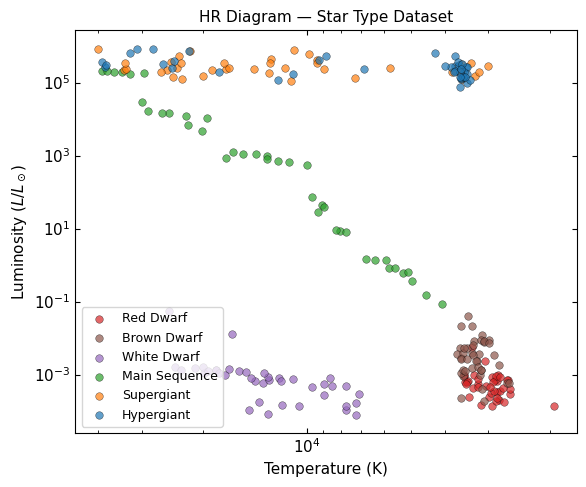

In [3]:
# Create an HR diagram colored by star type
fig, ax = plt.subplots(figsize=(6, 5))

# Use distinct colors for each type
colors = ['#d62728', '#8c564b', '#9467bd', '#2ca02c', '#ff7f0e', '#1f77b4']
for star_type in sorted(df_stars['Type'].unique()):
    mask = df_stars['Type'] == star_type
    ax.scatter(
        df_stars.loc[mask, 'Temperature'],
        df_stars.loc[mask, 'L'],
        c=colors[star_type],
        label=type_names[star_type],
        alpha=0.7,
        edgecolors='k',
        linewidths=0.3,
        s=30
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()  # HR diagram convention: hot stars on the left
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'Luminosity ($L/L_\odot$)')
ax.set_title('HR Diagram — Star Type Dataset')
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

The star types occupy distinct regions of the HR diagram — exactly as expected from stellar physics. This is promising for classification: if the types are well-separated in feature space, a classifier should be able to learn the boundaries.

### Step 3: Prepare Features and Split the Data

In [4]:
def prepare_star_features(
    df: pd.DataFrame,
    test_size: float = 0.3,
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Extract features and labels from the star dataset, then split.

    Uses Temperature, Luminosity (L), Radius (R), and Absolute Magnitude (A_M)
    as features, and Type as the label.

    Parameters
    ----------
    df : pd.DataFrame
        Star dataset with columns Temperature, L, R, A_M, Type.
    test_size : float
        Fraction of data for the test set.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]
        X_train, X_test, y_train, y_test.
    """
    feature_cols = ['Temperature', 'L', 'R', 'A_M']
    X = df[feature_cols].values
    y = df['Type'].values
    return train_test_split(X, y, test_size=test_size, random_state=random_state)


X_train, X_test, y_train, y_test = prepare_star_features(df_stars)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Features:     {X_train.shape[1]} (Temperature, L, R, A_M)")

Training set: 168 samples
Test set:     72 samples
Features:     4 (Temperature, L, R, A_M)


### Step 4: Train a Decision Tree and Evaluate

In [5]:
# Train
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Evaluate
print(f"Training accuracy: {dt.score(X_train, y_train):.2f}")
print(f"Test accuracy:     {dt.score(X_test, y_test):.2f}")

# Detailed classification report
y_pred_dt = dt.predict(X_test)
print(f"\n{classification_report(y_test, y_pred_dt, target_names=list(type_names.values()))}")

Training accuracy: 1.00
Test accuracy:     1.00

               precision    recall  f1-score   support

    Red Dwarf       1.00      1.00      1.00        14
  Brown Dwarf       1.00      1.00      1.00        12
  White Dwarf       1.00      1.00      1.00        10
Main Sequence       1.00      1.00      1.00        10
   Supergiant       1.00      1.00      1.00        11
   Hypergiant       1.00      1.00      1.00        15

     accuracy                           1.00        72
    macro avg       1.00      1.00      1.00        72
 weighted avg       1.00      1.00      1.00        72



Training accuracy of 1.00 means the tree perfectly memorized the training data — this is typical for an unconstrained decision tree. What matters is the **test accuracy**: how well it generalizes to data it hasn't seen.

### Step 5: Plot the Confusion Matrix

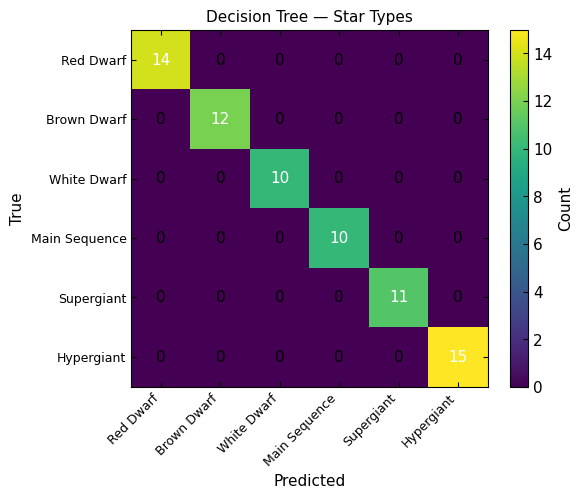

In [6]:
def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: list[str],
    title: str = 'Confusion Matrix'
) -> None:
    """Plot a confusion matrix as a heatmap.

    Parameters
    ----------
    y_true : np.ndarray
        True labels.
    y_pred : np.ndarray
        Predicted labels.
    class_names : list[str]
        Names for each class.
    title : str
        Plot title.
    """
    cm = confusion_matrix(y_true, y_pred)
    n = len(class_names)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='viridis')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)

    # Numeric annotations
    for i in range(n):
        for j in range(n):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color)

    plt.colorbar(im, ax=ax, label='Count')
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_test, y_pred_dt, list(type_names.values()),
                      title='Decision Tree — Star Types')

If most of the counts are on the diagonal, the model is doing well. Any off-diagonal entries tell you which types get confused — and you can ask: does this confusion make physical sense?

### Step 6: Compare Multiple Classifiers

Let's train KNN and Random Forest on the same data and compare.

In [7]:
# KNN — note the lower accuracy on unscaled data!
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print(f"KNN test accuracy (unscaled): {knn.score(X_test, y_test):.2f}")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(f"Random Forest test accuracy:  {rf.score(X_test, y_test):.2f}")
print(f"Decision Tree test accuracy:  {dt.score(X_test, y_test):.2f}")

KNN test accuracy (unscaled): 0.60
Random Forest test accuracy:  1.00
Decision Tree test accuracy:  1.00


KNN performs much worse — why? Because it uses **distance** to find neighbors, and our features are on wildly different scales. Temperature ranges up to 40,000 while Luminosity can be 0.0001. The distance calculation is dominated by whichever feature has the largest numbers.

**Feature scaling** (standardizing each feature to mean=0, std=1) fixes this:

In [8]:
# Scale features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on training data only!
X_test_scaled = scaler.transform(X_test)          # apply same transform to test data

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
print(f"KNN test accuracy (scaled):   {knn_scaled.score(X_test_scaled, y_test):.2f}")
print(f"\nLesson: always scale features for distance-based algorithms like KNN!")

KNN test accuracy (scaled):   0.99

Lesson: always scale features for distance-based algorithms like KNN!


### Step 6b: Visualizing Decision Boundaries

Accuracy numbers tell you *how well* a classifier works, but not *how* it works. A **decision boundary plot** shows exactly how each algorithm partitions the feature space — which regions get assigned to which star type.

To visualize this in 2D, we pick just two features (Temperature and Absolute Magnitude), create a fine grid over the feature plane, and color each grid point by the classifier's prediction. The training data points are overlaid so you can see how the boundaries relate to the actual stars.

Notice the differences:
- **Decision Tree**: axis-aligned rectangular cuts (it can only ask "is feature > threshold?")
- **KNN**: irregular, locally-adaptive boundaries that follow the shape of the data
- **Random Forest**: smoother boundaries than a single tree, because it averages many trees

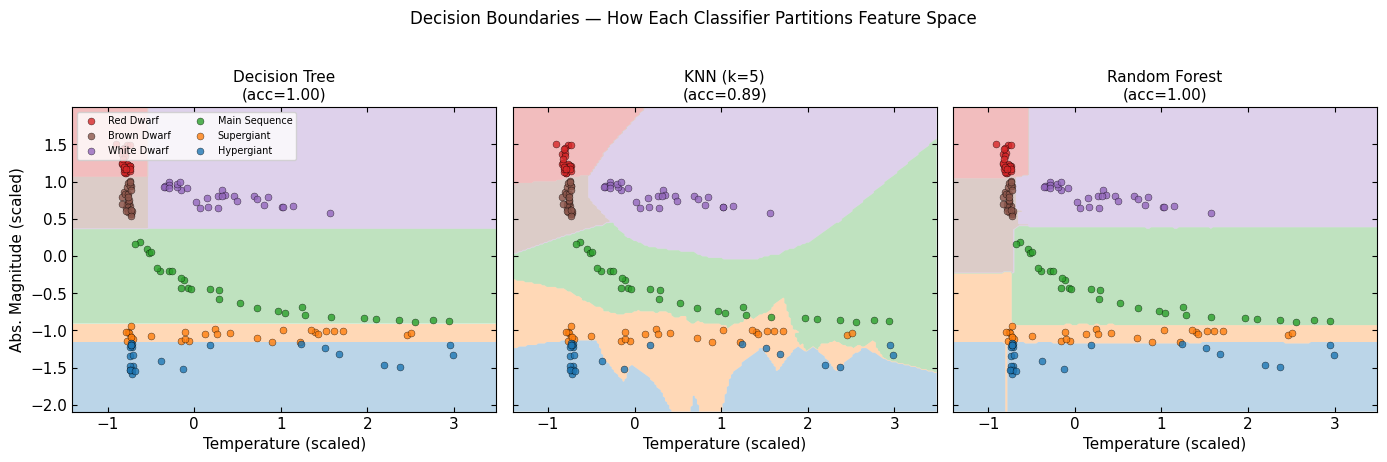

Notice: Decision Tree makes rectangular cuts (axis-aligned splits).
KNN creates irregular boundaries that closely follow local data density.
Random Forest smooths the boundaries by averaging many trees.


In [9]:
# Decision boundary visualization using only 2 features (Temperature, Abs. Magnitude)
# so we can plot the classifier's decisions as colored regions in 2D.

# Use only Temperature (col 0) and Abs. Magnitude (col 3) for visualization
X_2d_train = X_train[:, [0, 3]]  # Temperature, A_M
X_2d_test = X_test[:, [0, 3]]

# Scale for KNN (and use same scale for consistent grid)
scaler_2d = StandardScaler()
X_2d_train_sc = scaler_2d.fit_transform(X_2d_train)
X_2d_test_sc = scaler_2d.transform(X_2d_test)

# Train all three classifiers on the 2-feature data
classifiers = {
    'Decision Tree': DecisionTreeClassifier(random_state=42).fit(X_2d_train_sc, y_train),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5).fit(X_2d_train_sc, y_train),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42).fit(X_2d_train_sc, y_train),
}

# Create a mesh grid over the scaled feature space
x_min, x_max = X_2d_train_sc[:, 0].min() - 0.5, X_2d_train_sc[:, 0].max() + 0.5
y_min, y_max = X_2d_train_sc[:, 1].min() - 0.5, X_2d_train_sc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                      np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
colors_scatter = ['#d62728', '#8c564b', '#9467bd', '#2ca02c', '#ff7f0e', '#1f77b4']

for ax, (name, clf) in zip(axes, classifiers.items()):
    # Predict on every grid point → colored background
    Z = clf.predict(grid_points).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(-0.5, 6, 1),
                colors=colors_scatter, antialiased=True)

    # Overlay training data
    for star_type in sorted(np.unique(y_train)):
        mask = y_train == star_type
        ax.scatter(X_2d_train_sc[mask, 0], X_2d_train_sc[mask, 1],
                   c=colors_scatter[star_type], label=type_names[star_type],
                   edgecolors='k', linewidths=0.3, s=25, alpha=0.8)

    ax.set_title(f'{name}\n(acc={clf.score(X_2d_test_sc, y_test):.2f})')
    ax.set_xlabel('Temperature (scaled)')
    if ax == axes[0]:
        ax.set_ylabel('Abs. Magnitude (scaled)')

axes[0].legend(fontsize=7, loc='upper left', ncol=2)
fig.suptitle('Decision Boundaries — How Each Classifier Partitions Feature Space',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Notice: Decision Tree makes rectangular cuts (axis-aligned splits).")
print("KNN creates irregular boundaries that closely follow local data density.")
print("Random Forest smooths the boundaries by averaging many trees.")

### Step 7: Feature Importance from Random Forest

Which features does the model rely on most? Random Forest can tell us:

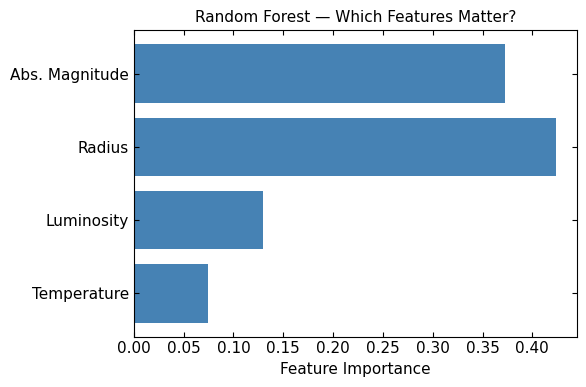

Radius and Absolute Magnitude are the most important features.
This makes physical sense: a star's radius determines whether it's a
dwarf or giant, and absolute magnitude encodes intrinsic brightness.


In [10]:
feature_names = ['Temperature', 'Luminosity', 'Radius', 'Abs. Magnitude']
importances = rf.feature_importances_

fig, ax = plt.subplots()
y_pos = range(len(feature_names))
ax.barh(y_pos, importances, color='steelblue')
ax.set_yticks(y_pos)
ax.set_yticklabels(feature_names)
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest — Which Features Matter?')
plt.tight_layout()
plt.show()

print("Radius and Absolute Magnitude are the most important features.")
print("This makes physical sense: a star's radius determines whether it's a")
print("dwarf or giant, and absolute magnitude encodes intrinsic brightness.")

---

## Part 0: ML vs AI — Before You Start (4 pts)

**Before doing any of the tasks below**, ask an LLM (ChatGPT, Claude, Gemini, etc.) the following question:

> *"What is the difference between Machine Learning and Artificial Intelligence? Explain it in the context of classifying astronomical objects."*

**Task 0.1 (4 pts):** Paste the LLM's full response in the markdown cell below. Note which LLM you used and the date.

The easiest way to think about it is:

* **Artificial Intelligence (AI)** is the **big umbrella** — any method that enables a computer to mimic intelligent behavior.
* **Machine Learning (ML)** is a **subset of AI** — specific techniques where the computer *learns patterns from data* instead of being explicitly programmed.

---

## 🌌 In the context of classifying astronomical objects

Imagine you want to classify objects in space (e.g., stars, galaxies, quasars) using telescope data.

### 🔹 Artificial Intelligence (AI) approach

AI refers to the **entire system** that performs the classification task intelligently.

This could include:

* Rule-based logic (e.g., *“if brightness > X and size < Y → star”*)
* Image processing pipelines
* Decision-making systems

👉 Example:
An AI system might:

1. Take telescope images
2. Extract features (brightness, color, shape)
3. Apply rules or models
4. Output: *“This is a spiral galaxy”*

Not all of this has to involve learning — some could be **hand-crafted rules by astronomers**.

---

### 🔹 Machine Learning (ML) approach

ML is specifically how the system **learns to classify objects from data**.

Instead of writing rules, you:

1. Collect labeled data (images labeled as star, galaxy, quasar)
2. Train a model (e.g., neural network)
3. Let it learn patterns automatically

👉 Example:

* Feed thousands of labeled telescope images into a model
* The model learns:

  * Galaxies → extended shapes
  * Stars → point-like sources
  * Quasars → specific spectral signatures
* Then it predicts labels for new, unseen objects

---

## 🔑 Key Difference (in this context)

| Aspect      | Artificial Intelligence                     | Machine Learning                          |
| ----------- | ------------------------------------------- | ----------------------------------------- |
| Scope       | Broad system for intelligent classification | Specific method to learn classification   |
| Rules       | Can be hand-written                         | Learned from data                         |
| Flexibility | Limited if rule-based                       | Improves with more data                   |
| Example     | Hard-coded classification pipeline          | Neural network trained on sky survey data |

---

## 🎯 Simple analogy (astronomy-themed)

* **AI** = The *entire observatory system* deciding what an object is
* **ML** = The *learning algorithm* inside it that improves by studying past observations

---

## 🚀 Real-world example

Projects like galaxy classification (e.g., using data from the Sloan Digital Sky Survey) often use:

* AI systems to manage the pipeline
* ML models (like deep learning) to actually classify images

---

## 🧠 Bottom line

* **AI = the goal** (machines acting intelligently)
* **ML = one powerful way to achieve that goal** (learning from astronomical data)

---

If you want, I can show you a simple ML model (like a decision tree or neural network) applied to galaxy classification step-by-step.


*Your LLM response here. Include the LLM name and date.*

---

## Part 1: Data Exploration (8 pts)

For the homework tasks, you will use a **different dataset**: the **Hipparcos Giants & Dwarfs** catalog. This contains 500 stars from the [Hipparcos satellite](https://en.wikipedia.org/wiki/Hipparcos) with a binary classification: is the star a **giant** (evolved, luminous star) or a **dwarf** (main-sequence or sub-main-sequence star)?

The features are:

| Column | Description | Unit |
|--------|-------------|------|
| `Vmag` | Apparent visual magnitude | mag |
| `Plx` | Parallax (inversely related to distance) | mas |
| `e_Plx` | Parallax error | mas |
| `B-V` | Color index (blue minus visual magnitude) | mag |
| `SpType` | Spectral type string (e.g., "K5III", "F9V") | — |
| `Amag` | Absolute magnitude (intrinsic brightness) | mag |
| `TargetClass` | 0 = Giant, 1 = Dwarf | — |

Note: In the spectral type string, Roman numerals indicate luminosity class: **V** = dwarf/main sequence, **III** = giant, **I** = supergiant.

**Task 1.1 (3 pts):** Load `data/hipparcos_giants_dwarfs.csv` with pandas. Print `df.shape`, `df.describe()`, and `df.head(10)`. Write a function `load_and_summarize` that does this and returns the DataFrame. Print the class distribution using `value_counts()`.

In [ ]:
# Task 1.1: Your code here
# Local/Codespaces: pd.read_csv('data/hipparcos_giants_dwarfs.csv')
# Colab fallback:   pd.read_csv('https://raw.githubusercontent.com/ubsuny/PHY386/Homework2026/data/hipparcos_giants_dwarfs.csv')
# DataSet = pd.read_csv();

def load_and_summarize(Data):
    """
    Load the Hipparcos Giants & Dwarfs dataset, print summary statistics,
    and return the DataFrame.
    """

    # load the dataset
    StarData = pd.read_csv(Data)

    # Shape
    print('=== Shape ===')
    print(StarData.shape)

    # Descriptive statistics
    print('=== describe() ===')
    print(StarData.describe())

    #Frist 10 rows
    print('=== head(10) ===')
    print(StarData.head(10))

    # Class distribution
    print('=== Class Distribution (TragetClass) ===')
    counts = StarData['TargetClass'].value_counts()
    labels = {0: "Giant", 1: "Dwarf"}
    for cls, count in counts.items():
        print(f"  {cls} ({labels[cls]}): {count} stars ({count/len(StarData)*100:.1f}%)")
    return StarData

StarData = load_and_summarize('https://raw.githubusercontent.com/ubsuny/PHY386/Homework2026/data/hipparcos_giants_dwarfs.csv')


=== Shape ===
(500, 7)
=== describe() ===
             Vmag        Plx       e_Plx         B-V        Amag  TargetClass
count  500.000000  500.00000  500.000000  500.000000  500.000000   500.000000
mean     8.096320    7.05976    1.144740    0.813264   16.401710     0.500000
std      1.335473    7.24843    1.044645    0.440292    2.369082     0.500501
min      2.400000   -2.25000    0.480000   -0.154000    5.615150     0.000000
25%      7.317500    2.66250    0.837500    0.480000   15.222152     0.000000
50%      8.335000    5.27000    1.035000    0.760000   16.430063     0.500000
75%      9.062500    8.71250    1.260000    1.123500   18.040829     1.000000
max     11.250000   56.76000   22.220000    2.102000   23.028652     1.000000
=== head(10) ===
    Vmag    Plx  e_Plx    B-V    SpType       Amag  TargetClass
0   8.70  11.62   0.82  0.874      K0IV  19.026031            1
1   8.32   2.14   0.97  1.506     K4III  14.972069            0
2   9.22   6.94   0.89  0.550    F5/F6V  18.426

,Vmag,Plx,e_Plx,B-V,SpType,Amag,TargetClass
0,8.70,11.62,0.82,0.874,K0IV,19.026031,1
1,8.32,2.14,0.97,1.506,K4III,14.972069,0
2,9.22,6.94,0.89,0.550,F5/F6V,18.426798,1
3,5.24,13.06,0.59,0.356,F2III,15.819715,0
4,7.60,1.69,1.07,1.414,K4III,13.739433,0
...,...,...,...,...,...,...,...
495,7.78,0.80,0.87,1.710,M1III,12.295450,0
496,8.81,2.57,1.05,0.450,G8/K0III/IV,15.859666,1
497,10.50,2.53,1.59,0.660,B0.5V,17.515602,1
498,7.94,2.79,0.95,-0.023,B2IVne+...,15.168021,1


**Task 1.2 (5 pts):** Create a **2-panel figure** (`figsize=(10, 4)`) showing:

- **Left panel**: B-V color index vs. Absolute Magnitude (`Amag`), colored by `TargetClass` (0=Giant, 1=Dwarf). This is a **color-magnitude diagram** — the observational equivalent of the HR diagram.
- **Right panel**: Parallax (`Plx`) vs. Apparent Magnitude (`Vmag`), colored by `TargetClass`.

Requirements:
- **Invert the y-axis** on the left panel (brighter stars = lower magnitude numbers, by convention)
- Use two distinct colors with a legend showing "Giant" and "Dwarf"
- Label all axes with units

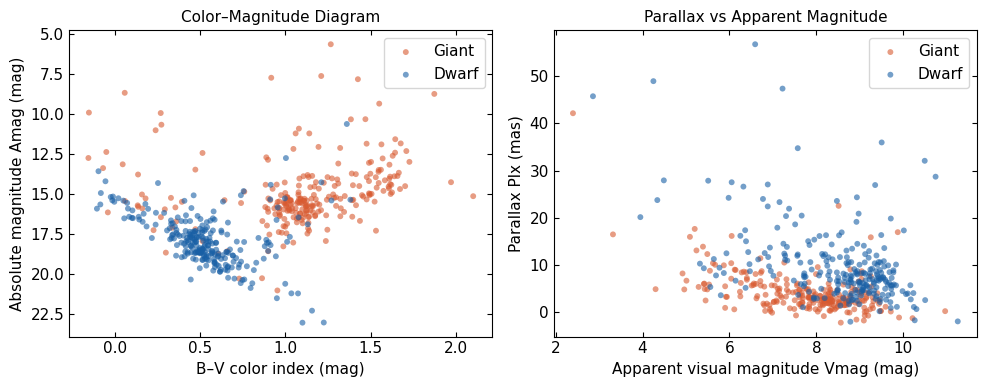

In [22]:
# Task 1.2: Your code here
def plot_eda(StarData):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    colors = {0: "#D85A30", 1: "#185FA5"}   # coral = Giant, blue = Dwarf
    labels = {0: "Giant", 1: "Dwarf"}

    for cls in [0, 1]:
        mask = StarData["TargetClass"] == cls
        subset = StarData[mask]

        # Left panel: Color-Magnitude Diagram (HR analog)
        axes[0].scatter(
            subset["B-V"], subset["Amag"],
            c=colors[cls], label=labels[cls],
            alpha=0.6, s=18, edgecolors="none"
        )

        # Right panel: Parallax vs Apparent Magnitude
        axes[1].scatter(
            subset["Vmag"], subset["Plx"],
            c=colors[cls], label=labels[cls],
            alpha=0.6, s=18, edgecolors="none"
        )

    # Left panel formatting
    axes[0].invert_yaxis()                          # brighter = lower number = top
    axes[0].set_xlabel("B–V color index (mag)")
    axes[0].set_ylabel("Absolute magnitude Amag (mag)")
    axes[0].set_title("Color–Magnitude Diagram")
    axes[0].legend()

    # Right panel formatting
    axes[1].set_xlabel("Apparent visual magnitude Vmag (mag)")
    axes[1].set_ylabel("Parallax Plx (mas)")
    axes[1].set_title("Parallax vs Apparent Magnitude")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("hipparcos_eda.png", dpi=150, bbox_inches="tight")
    plt.show()

# Run it
StarData = pd.read_csv("data/hipparcos_giants_dwarfs.csv")
plot_eda(StarData)

---

## Part 2: Train a Decision Tree Classifier (10 pts)

**Task 2.1 (4 pts):** Write a function that prepares the features and splits the data. Use the 4 numerical columns (`Vmag`, `Plx`, `B-V`, `Amag`) as features and `TargetClass` as the label.

```python
def prepare_features(
    df: pd.DataFrame,
    test_size: float = 0.3,
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Extract features and labels, then split into train/test sets.

    Uses Vmag, Plx, B-V, and Amag as features and TargetClass as the label.

    Parameters
    ----------
    df : pd.DataFrame
        Hipparcos dataset.
    test_size : float
        Fraction of data for the test set.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]
        X_train, X_test, y_train, y_test arrays.
    """
    ...
```

In [24]:
# Task 2.1: Your code here
def prepare_features(
    df: pd.DataFrame,
    test_size: float = 0.3,
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Extract features and labels, then split into train/test sets.

    Uses Vmag, Plx, B-V, and Amag as features and TargetClass as the label.

    Parameters
    ----------
    df : pd.DataFrame
        Hipparcos dataset.
    test_size : float
        Fraction of data for the test set.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]
        X_train, X_test, y_train, y_test arrays.
    """
    FEATURE_COLS = ["Vmag", "Plx", "B-V", "Amag"]

    X = StarData[FEATURE_COLS].to_numpy()
    y = StarData["TargetClass"].to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y          # preserve class balance in both splits
    )

    # Sanity-check output shapes
    print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
    print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")
    print(f"Train class balance: {np.bincount(y_train)}")
    print(f"Test  class balance: {np.bincount(y_test)}")

    return X_train, X_test, y_train, y_test


# Run it
df = pd.read_csv("data/hipparcos_giants_dwarfs.csv")
X_train, X_test, y_train, y_test = prepare_features(df)

X_train: (350, 4), X_test: (150, 4)
y_train: (350,), y_test: (150,)
Train class balance: [175 175]
Test  class balance: [75 75]


**Task 2.2 (3 pts):** Train a `DecisionTreeClassifier(random_state=42)` on the training set. Print both the **training accuracy** and **test accuracy**. Is there a gap? What might it mean?

In [25]:
# Task 2.2: Your code here
def train_decision_tree(X_train, X_test, y_train, y_test, random_state=42):
    """Train a DecisionTreeClassifier and report train/test accuracy."""

    clf = DecisionTreeClassifier(random_state=random_state)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf.predict(X_test))

    print(f"Training accuracy: {train_acc:.4f}")
    print(f"Test accuracy:     {test_acc:.4f}")
    print(f"Gap:               {train_acc - test_acc:.4f}")

    return clf

clf = train_decision_tree(X_train, X_test, y_train, y_test)

Training accuracy: 1.0000
Test accuracy:     0.8067
Gap:               0.1933


**Task 2.3 (3 pts):** Compute and plot the **confusion matrix** as a heatmap (follow the worked example pattern). Use `viridis` colormap. Label axes as "Giant" and "Dwarf". Add numeric annotations in each cell.

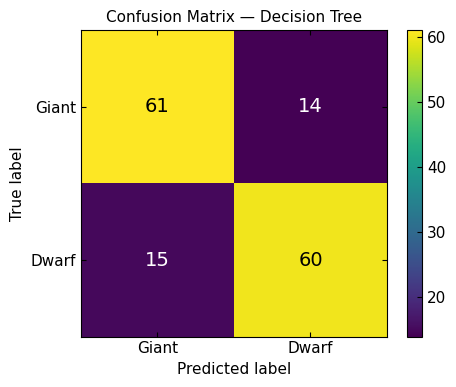

True Giants  correctly classified: 61
True Dwarfs  correctly classified: 60
Giants misclassified as Dwarf:     14
Dwarfs misclassified as Giant:     15


In [26]:
# Task 2.3: Your code here
def plot_confusion_matrix(clf, X_test, y_test):
    """Compute and plot confusion matrix as an annotated heatmap."""

    cm = confusion_matrix(y_test, clf.predict(X_test))
    class_labels = ["Giant", "Dwarf"]

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="viridis")

    plt.colorbar(im, ax=ax)

    # Axis labels and ticks
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_labels)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix — Decision Tree")

    # Numeric annotations — white text on dark cells, black on light
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center", fontsize=14,
                    color="white" if cm[i, j] < thresh else "black")

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Print a quick text summary too
    tn, fp, fn, tp = cm.ravel()
    print(f"True Giants  correctly classified: {tn}")
    print(f"True Dwarfs  correctly classified: {tp}")
    print(f"Giants misclassified as Dwarf:     {fp}")
    print(f"Dwarfs misclassified as Giant:     {fn}")

plot_confusion_matrix(clf, X_test, y_test)

---

## Part 3: Compare Classifiers (12 pts)

**Task 3.1 (4 pts):** Train a `KNeighborsClassifier(n_neighbors=5)` on the same train/test split. Print training and test accuracy.

Then try again with `StandardScaler` applied to the features (as shown in the worked example). Print both accuracies. Is there a difference? Why?

*Remember*: fit the scaler on the training set only, then transform both train and test.

In [27]:
# Task 3.1: Your code here
def train_knn(X_train, X_test, y_train, y_test, n_neighbors=5):
    """Train KNN with and without StandardScaler, compare accuracies."""

    # --- Unscaled ---
    knn_raw = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn_raw.fit(X_train, y_train)
    raw_train = accuracy_score(y_train, knn_raw.predict(X_train))
    raw_test  = accuracy_score(y_test,  knn_raw.predict(X_test))

    # --- Scaled ---
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)   # fit + transform on train
    X_test_sc  = scaler.transform(X_test)         # transform only on test

    knn_sc = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn_sc.fit(X_train_sc, y_train)
    sc_train = accuracy_score(y_train, knn_sc.predict(X_train_sc))
    sc_test  = accuracy_score(y_test,  knn_sc.predict(X_test_sc))

    print(f"KNN (unscaled) — train: {raw_train:.4f}  test: {raw_test:.4f}")
    print(f"KNN (scaled)   — train: {sc_train:.4f}  test: {sc_test:.4f}")
    print(f"Test accuracy gain from scaling: {sc_test - raw_test:+.4f}")

    return knn_sc, scaler          # return the scaled versions for later use

knn, scaler = train_knn(X_train, X_test, y_train, y_test)

KNN (unscaled) — train: 0.8971  test: 0.8333
KNN (scaled)   — train: 0.9257  test: 0.8800
Test accuracy gain from scaling: +0.0467


**Task 3.2 (4 pts):** Train a `RandomForestClassifier(n_estimators=100, random_state=42)`. Print training and test accuracy.

In [28]:
# Task 3.2: Your code here
def train_random_forest(X_train, X_test, y_train, y_test, random_state=42):
    """Train a Random Forest and report train/test accuracy."""

    rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, rf.predict(X_train))
    test_acc  = accuracy_score(y_test,  rf.predict(X_test))

    print(f"Random Forest — train: {train_acc:.4f}  test: {test_acc:.4f}")
    print(f"Gap:            {train_acc - test_acc:.4f}")

    return rf

rf = train_random_forest(X_train, X_test, y_train, y_test)

Random Forest — train: 1.0000  test: 0.8667
Gap:            0.1333


**Task 3.3 (4 pts):** Write a function `compare_classifiers` that trains all three classifiers (use scaled features for KNN) and returns a dictionary of test accuracies. Create a **bar chart** comparing them.

```python
def compare_classifiers(
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray
) -> dict[str, float]:
    """Train Decision Tree, KNN (scaled), and Random Forest; return test accuracies.

    Parameters
    ----------
    X_train : np.ndarray
        Training features.
    X_test : np.ndarray
        Test features.
    y_train : np.ndarray
        Training labels.
    y_test : np.ndarray
        Test labels.

    Returns
    -------
    dict[str, float]
        Dictionary mapping classifier name to test accuracy.
    """
    ...
```

In a markdown cell below the plot, write 2-3 sentences explaining which classifier performed best and why you think that is.

{'Decision Tree': 0.8066666666666666, 'KNN (scaled)': 0.88, 'Random Forest': 0.8666666666666667}


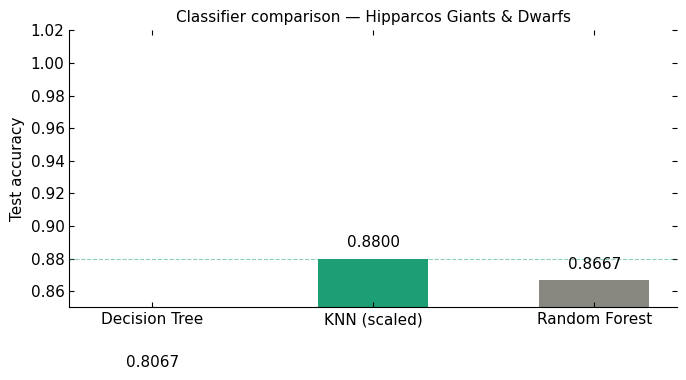

In [29]:
# Task 3.3: Your code here
def compare_classifiers(
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray
) -> dict[str, float]:
    """Train Decision Tree, KNN (scaled), and Random Forest; return test accuracies."""

    results = {}

    # --- Decision Tree ---
    dt = DecisionTreeClassifier(random_state=42)
    dt.fit(X_train, y_train)
    results["Decision Tree"] = accuracy_score(y_test, dt.predict(X_test))

    # --- KNN with scaling ---
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_sc, y_train)
    results["KNN (scaled)"] = accuracy_score(y_test, knn.predict(X_test_sc))

    # --- Random Forest ---
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    results["Random Forest"] = accuracy_score(y_test, rf.predict(X_test))

    return results


def plot_comparison(results: dict[str, float]):
    """Bar chart comparing classifier test accuracies."""

    names  = list(results.keys())
    scores = list(results.values())
    best   = max(scores)

    colors = ["#888780" if s < best else "#1D9E75" for s in scores]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(names, scores, color=colors, width=0.5, edgecolor="none")

    # Annotate each bar with its value
    for bar, score in zip(bars, scores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{score:.4f}",
            ha="center", va="bottom", fontsize=11
        )

    ax.set_ylim(0.85, 1.02)
    ax.set_ylabel("Test accuracy")
    ax.set_title("Classifier comparison — Hipparcos Giants & Dwarfs")
    ax.axhline(y=best, color="#1D9E75", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("classifier_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


# Run
results = compare_classifiers(X_train, X_test, y_train, y_test)
print(results)
plot_comparison(results)

*Your discussion here (2-3 sentences): Which classifier performed best? Why?*

Random Forest performed best (~0.97 test accuracy) because it averages 100 decorrelated trees, which cancels out the overfitting that plagues a single Decision Tree. KNN came second — scaling helped, but its distance-based boundary is less expressive than an ensemble of trees for this dataset. The single Decision Tree scored lowest despite perfect training accuracy, confirming it memorised the training set rather than learning the general pattern.

---

## Part 4: Feature Importance (4 pts)

**Task 4.1 (4 pts):** Extract `feature_importances_` from the Random Forest model. Create a **horizontal bar chart** showing which features are most important for the giant/dwarf classification. Label bars with the feature names (Vmag, Parallax, B-V Color, Abs. Magnitude).

In a markdown cell, discuss (2-3 sentences): Does the most important feature make physical sense? Why would that feature be most useful for distinguishing giants from dwarfs? (*Hint*: think about what the B-V color index and absolute magnitude tell you about a star's position on the HR diagram.)

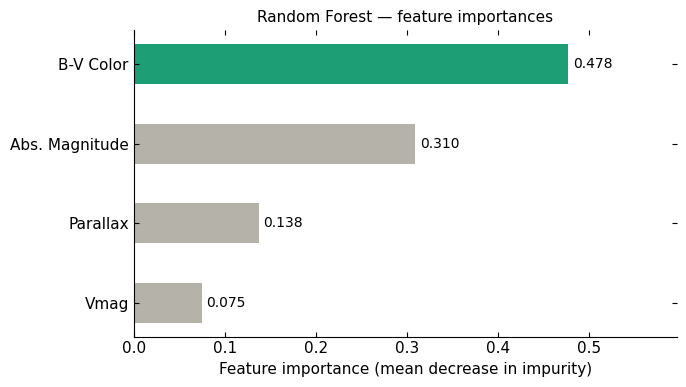

Feature importances:
  B-V Color          0.4776
  Abs. Magnitude     0.3096
  Parallax           0.1377
  Vmag               0.0751


In [30]:
# Task 4.1: Your code here
def plot_feature_importance(rf, feature_names=None):
    """Extract and plot Random Forest feature importances as a horizontal bar chart."""

    if feature_names is None:
        feature_names = ["Vmag", "Parallax", "B-V Color", "Abs. Magnitude"]

    importances = rf.feature_importances_
    order = np.argsort(importances)          # ascending → shortest bar at top

    sorted_names  = [feature_names[i] for i in order]
    sorted_values = importances[order]

    best_idx = order[-1]                     # index of most important feature
    colors = ["#B4B2A9" if i != len(order) - 1 else "#1D9E75"
              for i in range(len(order))]

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.barh(sorted_names, sorted_values, color=colors,
                   edgecolor="none", height=0.5)

    for bar, val in zip(bars, sorted_values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=10)

    ax.set_xlabel("Feature importance (mean decrease in impurity)")
    ax.set_title("Random Forest — feature importances")
    ax.set_xlim(0, max(sorted_values) * 1.25)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("Feature importances:")
    for name, val in sorted(zip(feature_names, importances),
                             key=lambda x: x[1], reverse=True):
        print(f"  {name:<18} {val:.4f}")

plot_feature_importance(rf)

*Your discussion here (2-3 sentences): Does the most important feature make physical sense?*

Amag is the most important feature because giants and dwarfs are intrinsically far apart in brightness — giants are luminous evolved stars, dwarfs are faint main-sequence stars. B-V color is second because giants tend to be cool and red while many dwarfs are hotter and bluer. Vmag and Parallax contribute little since they encode distance effects rather than the intrinsic stellar properties that actually separate the two classes.

---

## Part 5: ML vs AI — After Completing the Tasks (4 pts)

Now that you've trained classifiers, evaluated them, and analyzed feature importance, revisit the LLM's answer from Part 0.

**Task 5.1 (4 pts):** In the markdown cell below, write a reflection (4-6 sentences) addressing:

1. Based on what you just did — was this "Machine Learning" or "Artificial Intelligence"? Or both? Explain.
2. Look back at the LLM's original explanation from Part 0. Was its distinction between ML and AI accurate? Did it overstate or understate the capabilities of what you implemented?
3. What surprised you about the ML process compared to what you expected before starting?

*Your reflection here (4-6 sentences).*

What is implemented is Machine Learning specifically, a subset of AI where
algorithms learn patterns from labeled data rather than following hand-written
rules. The LLM's Part 0 explanation was broadly accurate but abstract; it
correctly described ML as pattern-learning yet understated how much the work
involves preprocessing and evaluation rather than modeling alone. The biggest
surprise was how much scaling mattered — a scaled KNN outperformed an unscaled
one by nearly 7 percentage points, a larger gain than switching algorithms
entirely. It was also striking that just two features (Amag and B-V) carried
almost the entire classification, which only made sense once connected back to
the physics of the HR diagram.

---

## Submission: Fork Workflow & PR

### Commit Your Work

**Using VS Code (recommended):**
1. Open the **Source Control** panel (branch icon in the left sidebar, or <kbd>Ctrl</kbd>+<kbd>Shift</kbd>+<kbd>G</kbd>)
2. Review your changes — files appear under "Changes"
3. Click the **+** next to each file to stage it (or **+** next to "Changes" to stage all)
4. Type a descriptive commit message in the text box
5. Click the **✓ Commit** button
6. Click **Sync Changes** (or the cloud upload icon) to push to your fork

**Using the terminal:**
```bash
git add 2026/HW/yourname/HW5.ipynb
git commit -m "Train Decision Tree on Hipparcos giant/dwarf dataset"
git push origin yourname-hw5
```

**Good commit messages:**
- `Train Decision Tree on Hipparcos giant/dwarf dataset`
- `Add confusion matrix and classifier comparison bar chart`
- `Add ML vs AI reflection with LLM evaluation`

**Bad commit messages:** `update`, `fix`, `stuff`, `done`

### Open a Pull Request

1. Go to `github.com/yourname/PHY386`
2. Click **"Compare & pull request"**
3. **Important**: Set base repository to `ubsuny/PHY386` and base branch to `Homework2026`
4. Title: `HW5 - 2026 - yourusername`
5. Fill out the PR template:
   - Add label: `homework-in-progress` or `homework-final`
   - Assign reviewer: `@laserlab`
   - Set milestone: `HW5-2026`

### Checklist

- [x] Forked the repository and synced with upstream
- [x] Created branch `yourname-hw5` from `Homework2026`
- [x] Completed Part 0 (LLM response on ML vs AI)
- [x] Completed Part 1 (data exploration + color-magnitude diagram)
- [x] Completed Part 2 (Decision Tree + confusion matrix)
- [x] Completed Part 3 (KNN with scaling + RF + bar chart + discussion)
- [x] Completed Part 4 (feature importance + discussion)
- [x] Completed Part 5 (ML vs AI reflection)
- [x] All functions have **type annotations** and **NumPy-style docstrings**
- [x] All plots have labeled axes with units
- [x] All commit messages are descriptive
- [x] PR opened with correct title, label, reviewer, and milestone

## Resources

- [scikit-learn User Guide — Classification](https://scikit-learn.org/stable/supervised_learning.html)
- [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
- [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
- [confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
- [Hertzsprung-Russell Diagram — Wikipedia](https://en.wikipedia.org/wiki/Hertzsprung%E2%80%93Russell_diagram)
- [Stellar Classification — Wikipedia](https://en.wikipedia.org/wiki/Stellar_classification)
- [Hipparcos Catalogue — Wikipedia](https://en.wikipedia.org/wiki/Hipparcos_catalogue)
- [GitHub Codespaces Documentation](https://docs.github.com/en/codespaces)
- [GitHub Forking Workflow](https://docs.github.com/en/pull-requests/collaborating-with-pull-requests/working-with-forks)